In [1]:
%load_ext autoreload
%autoreload 2
import sys
import bm3d, bm4d
from pickle import dump,load
import re
import seaborn as sns
import tifffile as tiff

sys.path.append("..")
from src import *

Cupy Available= 1


# Denoising with Block-Matching algorithms

BM3D and BM4D were the State-of-the-art in image denoising back in 2010. How do they perform when compared to DeepCAD?

In [2]:
MAX_FRAMES = 3_000
meta = DATASETS["synthetic"]
x = Recording(meta.x, max_frames=MAX_FRAMES, norm=True)
gt = Recording(meta.gt, max_frames=MAX_FRAMES, norm=True)
metrics = {}

The values must be ranged 0-1 because `sigma_psd` depends on it.

## BM3D denoising

In [ ]:
# 1s
FRAME=-1
y_bm3d = bm3d.bm3d(x.np[FRAME], sigma_psd=0.2, stage_arg=bm3d.BM3DStages.ALL_STAGES)

In [3]:
MAX_FRAMES = 3000
y_bm4d = np.empty((MAX_FRAMES, *meta.shape[1:]))
for i in trange(MAX_FRAMES):
    y_bm4d[i] = bm3d.bm3d(x.np[i], sigma_psd=0.2, stage_arg=bm3d.BM3DStages.ALL_STAGES)

100%|██████████| 3000/3000 [39:07<00:00,  1.28it/s]


In [4]:
tiff.imwrite(f"bm3d.tiff", y_bm4d)

In [ ]:
metrics["bm3d"] = tuple(m(gt.np[FRAME], y_bm3d, data_range=1) for m in (psnr, ssim))
cprint("PSNR", "red:(BM3D)", "-->", f"green:{metrics["bm3d"][0]:.2f}dB")
cprint("SSIM", "red:(BM3D)", "-->", f"green:{metrics["bm3d"][1]:.3f}")

PSNR (BM3D) --> 11.47dB
SSIM (BM3D) --> 0.236


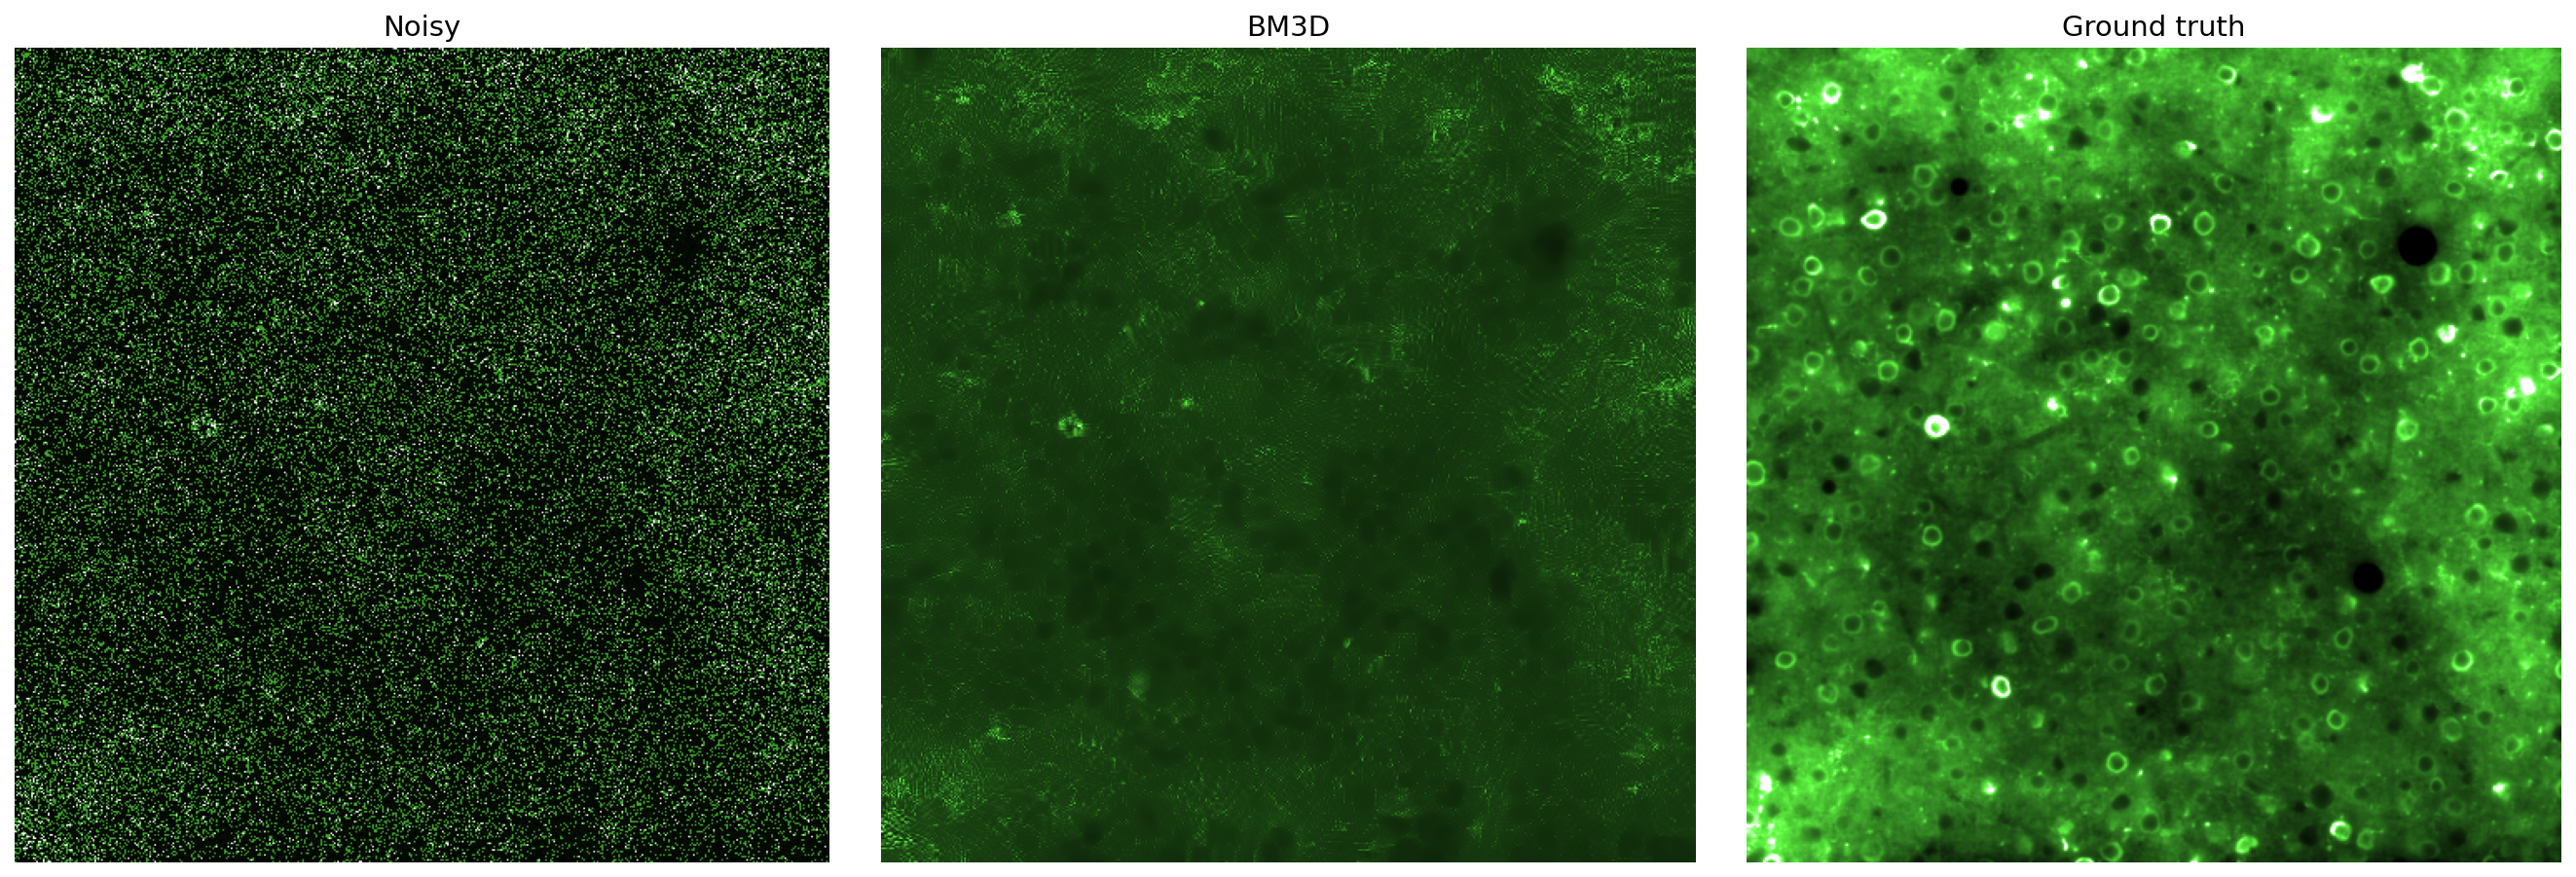

In [27]:
imshow({"Noisy":x.np[FRAME], "BM3D":y_bm3d, "Ground truth":gt.np[FRAME]}, size=6)

BM3D is meant to be used with natural images. It does not perform well with neuroscience images. But BM4D will perform much better because we have a video with independent noise at pixel and frame level.

## BM4D

In [3]:
# 7.5s/frame (scales O(n) with the number of frames)
MAX_FRAMES = 3000
PATCH_T = 8
y_bm4d = np.empty((MAX_FRAMES, *meta.shape[1:]))
for i in trange(0, MAX_FRAMES, PATCH_T):
    y_bm4d[i : i + PATCH_T] = bm4d.bm4d(x.np[i : i + PATCH_T], sigma_psd=0.2, stage_arg=bm3d.BM3DStages.ALL_STAGES)

  0%|          | 0/375 [00:00<?, ?it/s]

100%|██████████| 375/375 [48:08<00:00,  7.70s/it]


In [ ]:
tiff.imwrite(f"bm4d_{PATCH_T}.tiff", y_bm4d)

In [ ]:
metrics["bm4d"] = tuple(m(gt.np[:MAX_FRAMES], y_bm4d) for m in (psnr3d, ssim3d))
cprint("PSNR", "red:(BM4D)", "-->", f"green:{metrics["bm4d"][0]:.2f}dB")
cprint("SSIM", "red:(BM4D)", "-->", f"green:{metrics["bm4d"][1]:.3f}")

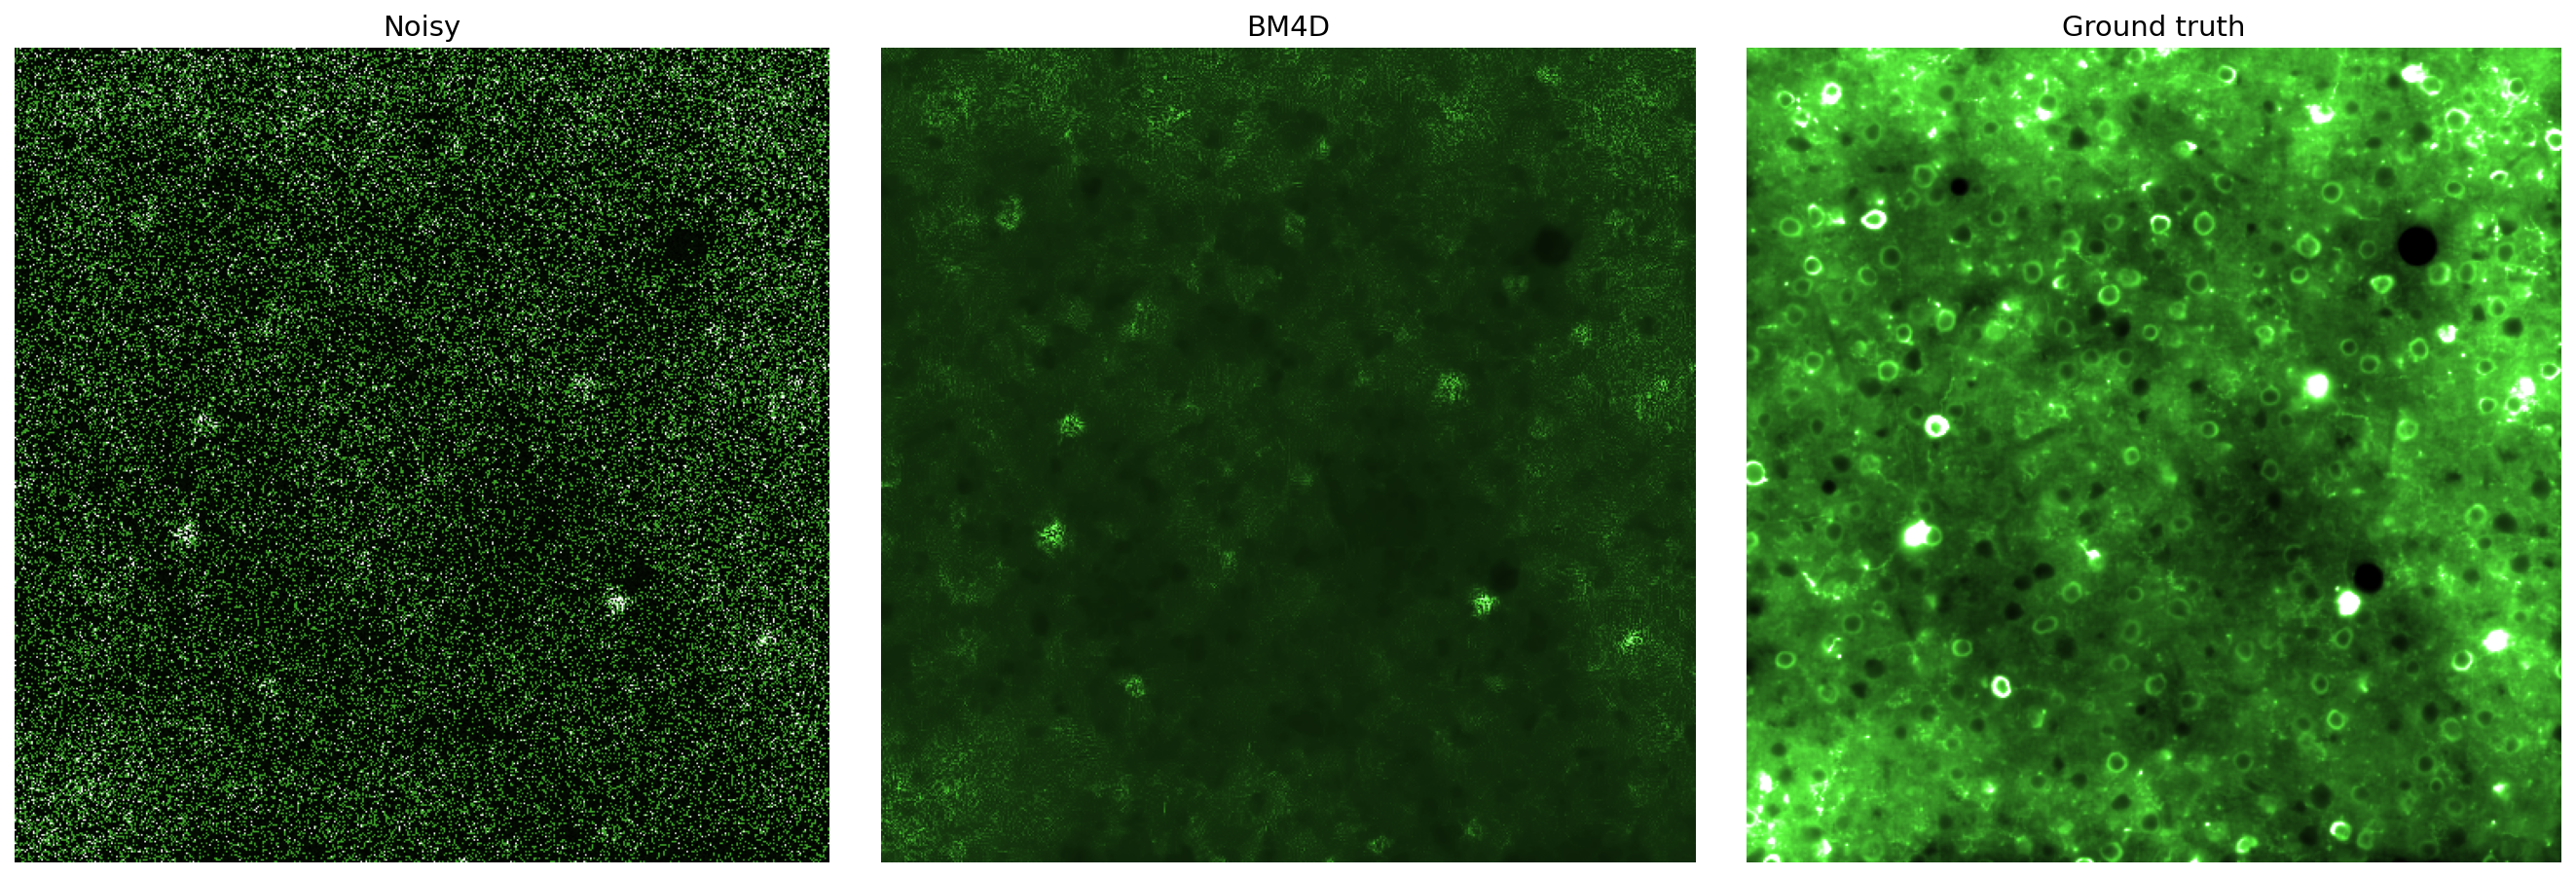

In [5]:
imshow({"Noisy": x.np[MAX_FRAMES // 2], "BM4D": y_bm4d[MAX_FRAMES // 2], "Ground truth": gt.np[MAX_FRAMES // 2]}, size=6)

BM4D (Maggioni et al. 2012) is much better than BM3D (Dabov et al. 2007), but too computational expensive.

## Grid Search results

In [ ]:
df = pd.read_csv("bm_results/metrics.csv", index_col="suffx")
df_bm3d = df[df.index.str.contains("bm3d")]
df_bm4d = df[df.index.str.contains("bm4d")]
sigma_ext = lambda s: float(re.search(r"\_σ(\d+\.?\d*)\_", s).group(1))
t_ext = lambda s: int(re.search(r"\_t(\d+)\_", s).group(1))

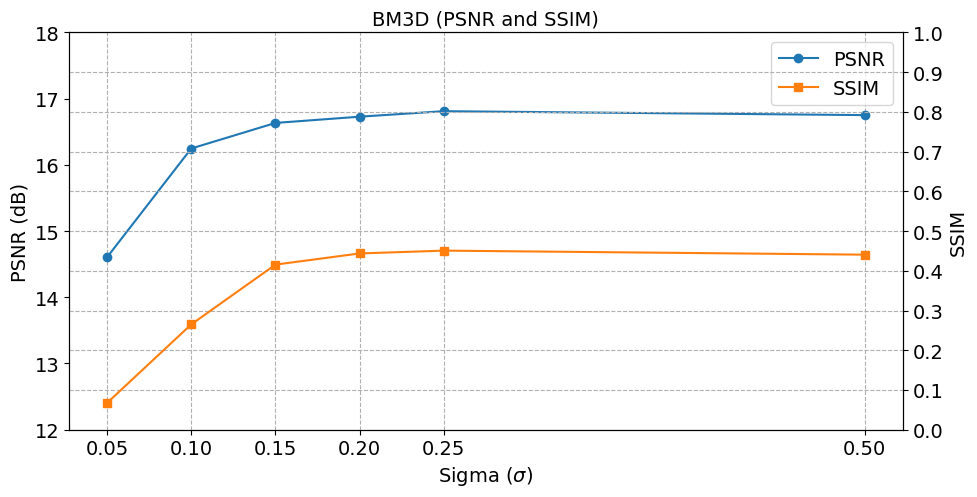

In [ ]:
df_bm3d["sigma"] = df_bm3d.index.map(sigma_ext)
df_bm3d = df_bm3d.sort_values("sigma")
fig, ax1 = plt.subplots(figsize=(10, 5.2))

color = "tab:blue"
ax1.set_xlabel("Sigma ($\sigma$)")
ax1.set_ylabel("PSNR (dB)")
ax1.plot(df_bm3d["sigma"], df_bm3d["PSNR"], color=color, marker="o", label="PSNR")
ax1.set_ylim(12, 18)
ax1.grid(False, axis="y")
ax1.set_xticks(df_bm3d.sigma)

ax2 = ax1.twinx()
color = "tab:orange"
ax2.set_ylabel("SSIM")
ax2.plot(df_bm3d["sigma"], df_bm3d["SSIM"], color=color, marker="s", label="SSIM")
ax2.set_ylim(0, 1)
ax2.set_yticks([0.1 * i for i in range(11)])
ax2.grid(True)

plt.title("BM3D (PSNR and SSIM)")
fig.tight_layout()
plt.grid(True)
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2)
plt.show()

C:\Users\MrPio\AppData\Local\Temp\ipykernel_21004\273488000.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bm4d["patch_t"] = df_bm4d.index.map(t_ext)

C:\Users\MrPio\AppData\Local\Temp\ipykernel_21004\273488000.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bm4d["sigma"] = df_bm4d.index.map(sigma_ext)



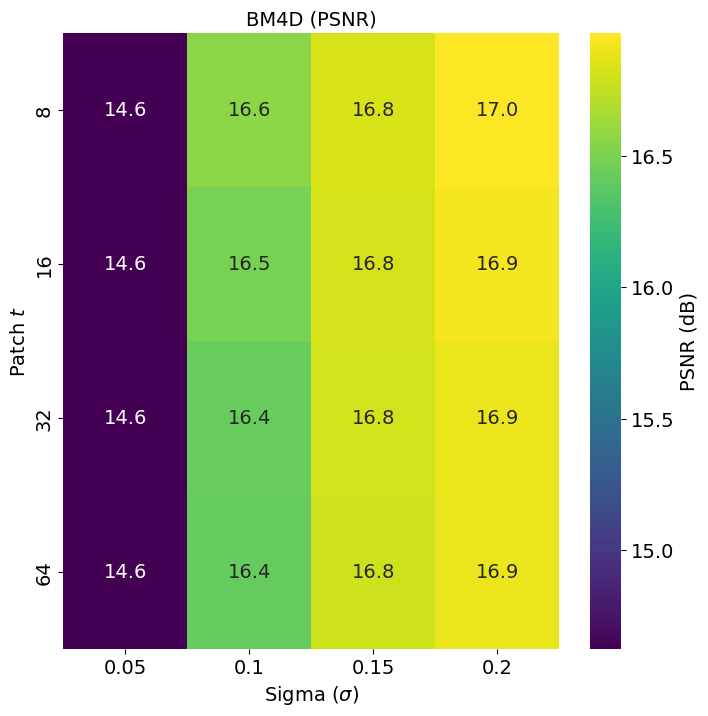

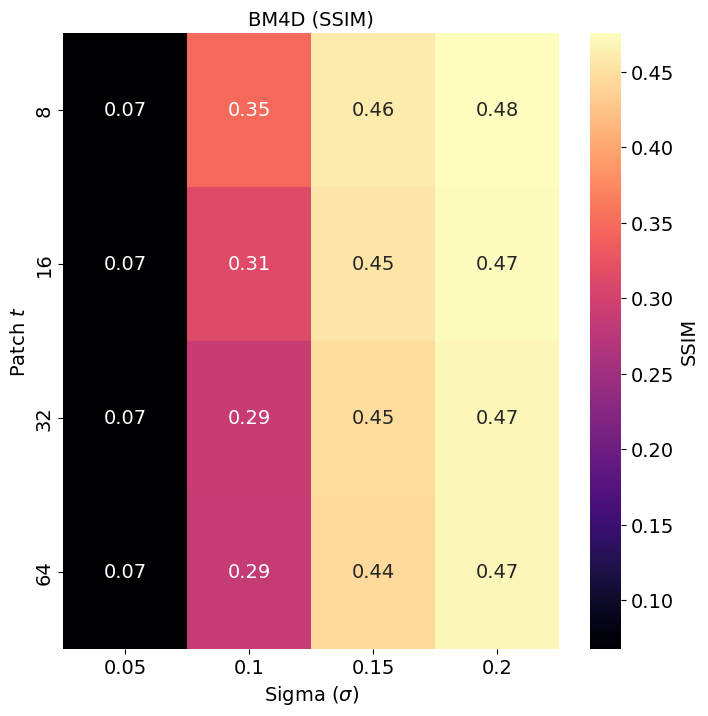

In [8]:
df_bm4d["patch_t"] = df_bm4d.index.map(t_ext)
df_bm4d["sigma"] = df_bm4d.index.map(sigma_ext)
psnr_matrix = df_bm4d.pivot(index="patch_t", columns="sigma", values="PSNR")

plt.figure(figsize=(8, 8))
sns.heatmap(psnr_matrix, annot=True, fmt=".1f", cmap="viridis", cbar_kws={"label": "PSNR (dB)"})
plt.title("BM4D (PSNR)")
plt.xlabel("Sigma ($\sigma$)")
plt.ylabel("Patch $t$")
plt.grid(False)
plt.show()

ssim_matrix = df_bm4d.pivot(index="patch_t", columns="sigma", values="SSIM")
plt.figure(figsize=(8, 8))
sns.heatmap(ssim_matrix, annot=True, fmt=".2f", cmap="magma", cbar_kws={"label": "SSIM"})
plt.title("BM4D (SSIM)")
plt.xlabel("Sigma ($\sigma$)")
plt.ylabel("Patch $t$")
plt.grid(False)
plt.show()

**Neither *BM3D* nor *BM4D* can compare to DeepCAD-RT**. They are too computationally expensive and are not intended for natural imaging denoising, where the principle of *sparsity under a transform domain* applies.